# loss.ipynb

# Import

In [2]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as colors
import seaborn.colors.xkcd_rgb as c

# !!

In [98]:
figpath = '../../Figure/vae'

# Plot loss

In [23]:
loss_path = '../../data/vae_model/loss_log'

In [134]:
def Plot_loss(season:str, savefig=False):
    # Load loss log
    with open(f'{loss_path}/{season}_vae_loss.txt', 'rb') as f:
        loss_log = pickle.load(f)
        
    # print(f"Max. KL-Div. loss in training: {np.asarray(loss_log['kl_loss']).max()}")
    # print(f"Max. KL-Div. loss in validation: {np.asarray(loss_log['val_kl_loss']).max()}")

    # Figure
    fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharex=True, sharey=True, gridspec_kw={'wspace':0.07})
    
    ## Training
    ax[0].grid(ls=':', lw=0.5, color='grey')
    ax[0].plot(loss_log['loss'], color='k', lw=4, label='Total')
    ax[0].plot(loss_log['reconstruction_loss'], color=c['bluish'], ls=':', lw=4, label='Reconstruction')
    ax[0].plot(loss_log['kl_loss'], color=c['scarlet'], ls='--', lw=4, label='KL Divergence')

    ax[0].set_xticks(np.arange(0, 400.1, 100))
    ax[0].set_xticklabels(np.arange(0, 400.1, 100).astype(int), fontsize=13)
    ax[0].set_xlabel('Epochs', fontsize=13)
    ax[0].set_yticks(np.arange(0, 4.1e6, 1e6))
    ax[0].tick_params(axis='y', labelsize=13)
    ax[0].yaxis.get_offset_text().set_fontsize(13)
    ax[0].set_ylabel('Loss', fontsize=13)
    ax[0].legend(fontsize=13)
    ax[0].set_title('Training', fontsize=16)

    ## Validation
    ax[1].grid(ls=':', lw=0.5, color='grey')
    ax[1].plot(loss_log['val_loss'], color='k', lw=4)
    ax[1].plot(loss_log['val_reconstruction_loss'], color=c['bluish'], ls=':', lw=4)
    ax[1].plot(loss_log['val_kl_loss'], color=c['scarlet'], ls='--', lw=4)
    
    ax[1].set_xticks(np.arange(0, 400.1, 100))
    ax[1].set_xticklabels(np.arange(0, 400.1, 100).astype(int), fontsize=13)
    ax[1].set_xlabel('Epochs', fontsize=13)
    ax[1].set_title('Validation', fontsize=16)
    
    fig.suptitle(x=0.5, y=1, t=f'{season.title()} VAE', fontsize=18, fontweight='bold')

    if savefig:
        plt.savefig(f'{figpath}/{season}_vae_loss.png', bbox_inches='tight', facecolor='w', dpi=400)
    plt.show()

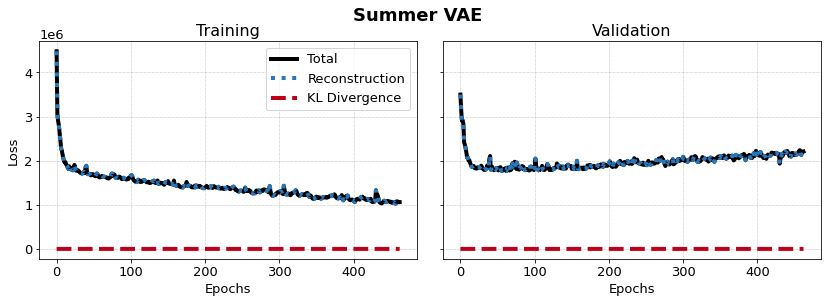

In [135]:
Plot_loss('summer', savefig=False)

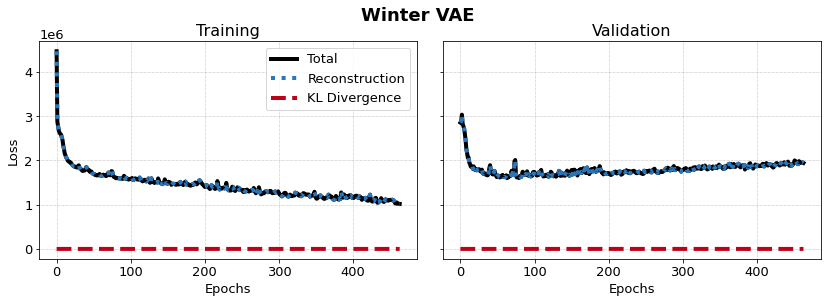

In [136]:
Plot_loss('winter', savefig=False)